In [2]:
import pandas as pd

hitters_full = pd.read_csv('../Data/Hitters.csv')

hitters_full.head(5)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [3]:
hitters_full.describe().round(2)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,263.00
mean,380.93,101.02,10.77,50.91,48.03,38.74,7.44,2648.68,717.57,69.49,358.80,330.12,260.24,288.94,106.91,8.04,535.93
std,153.40,46.45,8.71,26.02,26.17,21.64,4.93,2324.21,654.47,86.27,334.11,333.22,267.06,280.70,136.85,6.37,451.12
min,16.00,1.00,0.00,0.00,0.00,0.00,1.00,19.00,4.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,67.50
25%,255.25,64.00,4.00,30.25,28.00,22.00,4.00,816.75,209.00,14.00,100.25,88.75,67.25,109.25,7.00,3.00,190.00
50%,379.50,96.00,8.00,48.00,44.00,35.00,6.00,1928.00,508.00,37.50,247.00,220.50,170.50,212.00,39.50,6.00,425.00
75%,512.00,137.00,16.00,69.00,64.75,53.00,11.00,3924.25,1059.25,90.00,526.25,426.25,339.25,325.00,166.00,11.00,750.00
max,687.00,238.00,40.00,130.00,121.00,105.00,24.00,14053.00,4256.00,548.00,2165.00,1659.00,1566.00,1378.00,492.00,32.00,2460.00


In [4]:
hitters_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    str    
 14  Division   322 non-null    str    
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    str    
dtypes: float64(1), int64(

In [5]:
hitters_full.dropna(inplace=True)
hitters_full.shape

(263, 20)

In [6]:
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

hitters_full = pd.get_dummies(hitters_full, drop_first=True)

X = hitters_full.drop(columns='Salary')
y = hitters_full['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

lasso_pipeline = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=42))

X_train.shape, X_test.shape


((184, 19), (79, 19))

In [7]:
hitters_full.head(5)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False


In [8]:
lasso_pipeline.fit(X_train, y_train)


c:\Users\Sebastian!\Documents\Programmering\Machine_Learning_SEBASTIAN_PETERSSON\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.679e+03, tolerance: 3.017e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Sebastian!\Documents\Programmering\Machine_Learning_SEBASTIAN_PETERSSON\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.753e+03, tolerance: 3.017e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Sebastian!\Documents\Programmering\Machine_Learning_SEBASTIAN_PETERSSON\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: Converge

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


In [9]:
coefficients = lasso_pipeline.named_steps['lassocv'].coef_
columns = X.columns

coef_df = pd.DataFrame({
    'feature': columns,
    'coefficient': coefficients
})

coef_df = coef_df[coef_df['coefficient'] != 0].sort_values(
    by='coefficient', key=lambda s: s.abs(), ascending=False
).reset_index(drop=True)
selected_features = coef_df['feature'].tolist()

coef_df


,feature,coefficient
0,Hits,166.571784
1,CRuns,149.238792
2,PutOuts,81.863661
3,AtBat,-57.690497
4,Division_W,-42.688747
5,CHmRun,31.396987
6,HmRun,29.584216
7,League_N,29.252395
8,Walks,24.621983
9,CRBI,22.007765


In [10]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

ridge_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    RidgeCV(cv=5)
)

elasticnet_pipeline = make_pipeline(
    StandardScaler(),
    ElasticNetCV(cv=5, l1_ratio=[0.1, 0.5, 0.9, 1.0], random_state=42)
)

ridge_pipeline.fit(X_train_selected, y_train)
elasticnet_pipeline.fit(X_train_selected, y_train)

ridge_pred = ridge_pipeline.predict(X_test_selected)
elasticnet_pred = elasticnet_pipeline.predict(X_test_selected)


In [11]:
pd.Series({
    'lasso_rmse': root_mean_squared_error(y_test, lasso_pipeline.predict(X_test)),
    'ridge_poly_rmse': root_mean_squared_error(y_test, ridge_pred),
    'elasticnet_rmse': root_mean_squared_error(y_test, elasticnet_pred)
}).round(2)


lasso_rmse         392.03
ridge_poly_rmse    348.49
elasticnet_rmse    394.92
dtype: float64

In [12]:
pd.Series({
    'n_selected_features': len(selected_features),
    'ridge_alpha': ridge_pipeline.named_steps['ridgecv'].alpha_,
    'elasticnet_alpha': elasticnet_pipeline.named_steps['elasticnetcv'].alpha_,
    'elasticnet_l1_ratio': elasticnet_pipeline.named_steps['elasticnetcv'].l1_ratio_
})


n_selected_features    11.000000
ridge_alpha            10.000000
elasticnet_alpha        0.753096
elasticnet_l1_ratio     0.500000
dtype: float64

In [13]:
hitters_full['Salary'].describe()

count     263.000000
mean      535.925882
std       451.118681
min        67.500000
25%       190.000000
50%       425.000000
75%       750.000000
max      2460.000000
Name: Salary, dtype: float64

<Axes: >

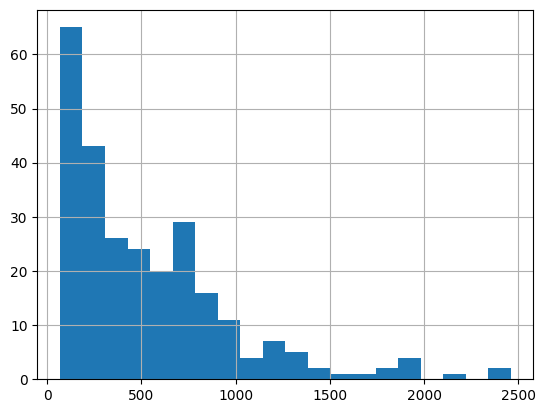

In [14]:
hitters_full['Salary'].hist(bins=20)

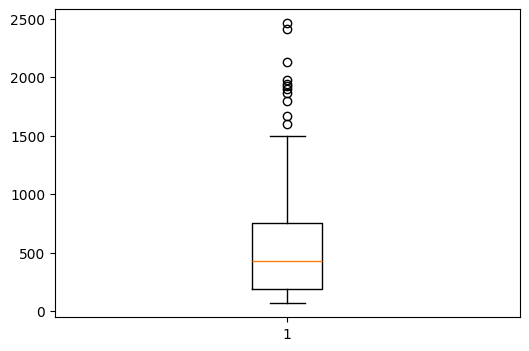

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

plt.boxplot(hitters_full['Salary'])
plt.show()

In [16]:
selected_features


['Hits',
 'CRuns',
 'PutOuts',
 'AtBat',
 'Division_W',
 'CHmRun',
 'HmRun',
 'League_N',
 'Walks',
 'CRBI',
 'Errors']